# Layer 1: Exploratory Data Analysis

**Objective:** Understand the shape, quality, and distribution of the scraped supermarket dataset.

**Input:** `data/processed/normalized_data.csv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# --- Premium Global Styling ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#ced4da',
    'axes.labelcolor':  '#212529',
    'axes.titleweight': 'bold',
    'axes.titlesize':   18,
    'axes.labelsize':   12,
    'font.family':      'sans-serif',
    'grid.color':       '#dee2e6',
    'grid.linestyle':   '--'
})
sns.set_theme(style='whitegrid', font_scale=1.1)
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}
BASE_DIR = Path(os.getcwd()).parent
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# ------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import os

# ── Premium Theme ──
plt.rcParams.update({
    'figure.facecolor': '#fafafa',
    'axes.facecolor':   '#fafafa',
    'font.family':      'sans-serif',
    'axes.titleweight':  'bold',
    'axes.titlesize':    16,
    'axes.labelsize':    13,
})
sns.set_theme(style='whitegrid')
sns.set_context('talk')

STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}
STORE_PAL    = [STORE_COLORS[s] for s in sorted(STORE_COLORS)]

BASE_DIR    = Path(os.getcwd()).parent
DATA_DIR    = BASE_DIR / 'data'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / 'processed' / 'normalized_data.csv', low_memory=False)
print(f'Rows: {len(df):,} | Stores: {df["store_name"].nunique()} | Cities: {df["city"].nunique()}')
df.head(3)

Rows: 183,792 | Stores: 3 | Cities: 16


,store_name,city,product_name_clean,brand_clean,price_clean,size_normalized,unit_normalized,price_per_unit,category_normalized,image_url,product_url,scraped_at
0,Al-Fatah,Faisalabad,aquafina pure drinking water 500ml-carton,Aquafina,540.0,500.0,ml,1.08,Grocery Staples,https://alfatah.pk/cdn/shop/files/AFP-00011558...,https://alfatah.pk/products/aquafina-pure-drin...,2026-03-08T20:17:01.040530
1,Al-Fatah,Faisalabad,aquafina pure drinking water 500 ml,Aquafina,45.0,500.0,ml,0.09,Grocery Staples,https://alfatah.pk/cdn/shop/files/1057363-1.jp...,https://alfatah.pk/products/aquafina-pure-drin...,2026-03-08T20:17:01.040530
2,Al-Fatah,Faisalabad,ff denali water 330 ml,Unknown,0.0,330.0,ml,0.00,Grocery Staples,https://alfatah.pk/cdn/shop/files/180402876961...,https://alfatah.pk/products/ff-denali-water-1-...,2026-03-08T20:17:01.040530


## 1.1 — Dataset Composition

C:\Users\Nouman\AppData\Local\Temp\ipykernel_5764\3167625650.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=city_data.index, x=city_data.values, ax=axes[1], palette='mako', edgecolor='black', linewidth=0.5)
C:\Users\Nouman\AppData\Local\Temp\ipykernel_5764\3167625650.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=cat_data.index, x=cat_data.values, ax=axes[2], palette='viridis', edgecolor='black', linewidth=0.5)


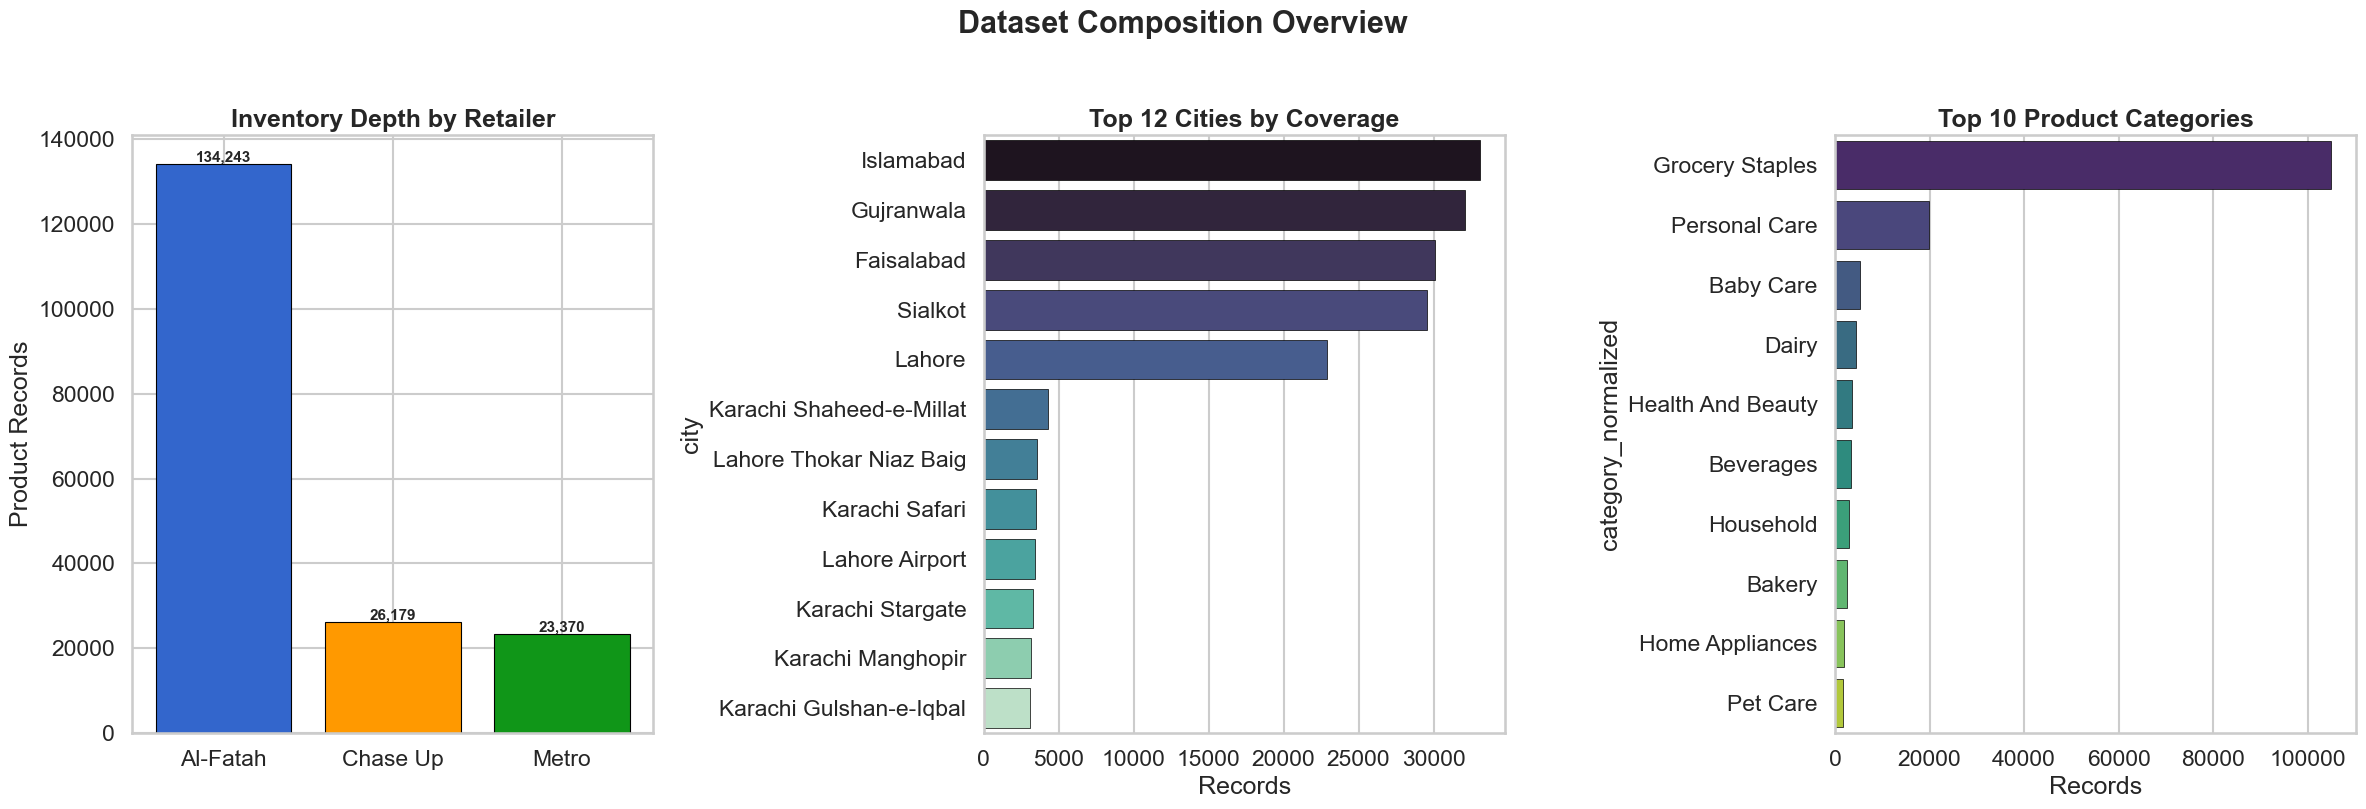

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Store Inventory Depth
store_counts = df['store_name'].value_counts()
bars = axes[0].bar(store_counts.index, store_counts.values,
                   color=[STORE_COLORS.get(s,'grey') for s in store_counts.index],
                   edgecolor='black', linewidth=0.8)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+500,
                f'{int(b.get_height()):,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Inventory Depth by Retailer')
axes[0].set_ylabel('Product Records')

# Top Cities
city_data = df['city'].value_counts().head(12)
sns.barplot(y=city_data.index, x=city_data.values, ax=axes[1], palette='mako', edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 12 Cities by Coverage')
axes[1].set_xlabel('Records')

# Top Categories
cat_data = df['category_normalized'].value_counts().head(10)
sns.barplot(y=cat_data.index, x=cat_data.values, ax=axes[2], palette='viridis', edgecolor='black', linewidth=0.5)
axes[2].set_title('Top 10 Product Categories')
axes[2].set_xlabel('Records')

plt.suptitle('Dataset Composition Overview', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.2 — Price Distribution Analysis

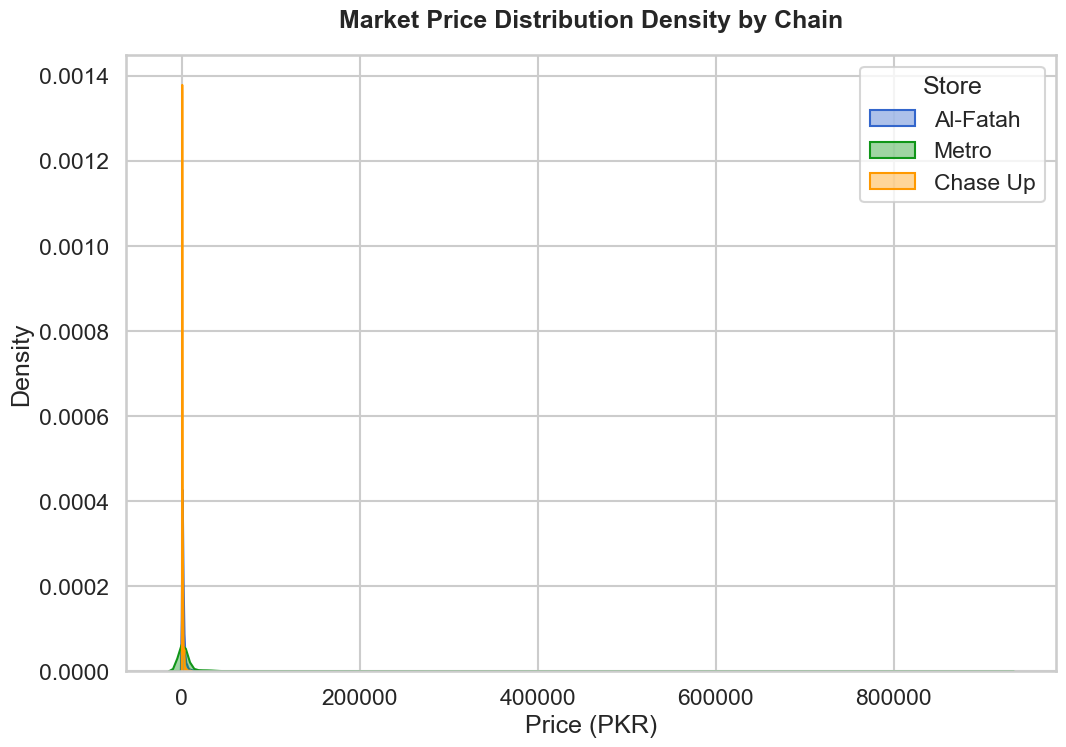

In [3]:
# Professional Price Distribution (Premium KDE)
plt.figure(figsize=(12, 8))
# Filter out extreme outliers for better visualization if needed
for store, color in STORE_COLORS.items():
    subset = df[df['store_name'] == store]
    sns.kdeplot(data=subset, x='price_clean', fill=True, label=store, color=color, alpha=0.4)
plt.title("Market Price Distribution Density by Chain", pad=20)
plt.xlabel("Price (PKR)")
plt.ylabel("Density")
plt.legend(title="Store")
plt.savefig(FIGURES_DIR / '01_price_distribution.png', dpi=300)
plt.show()

## 1.3 — Category Price Ridge Plot

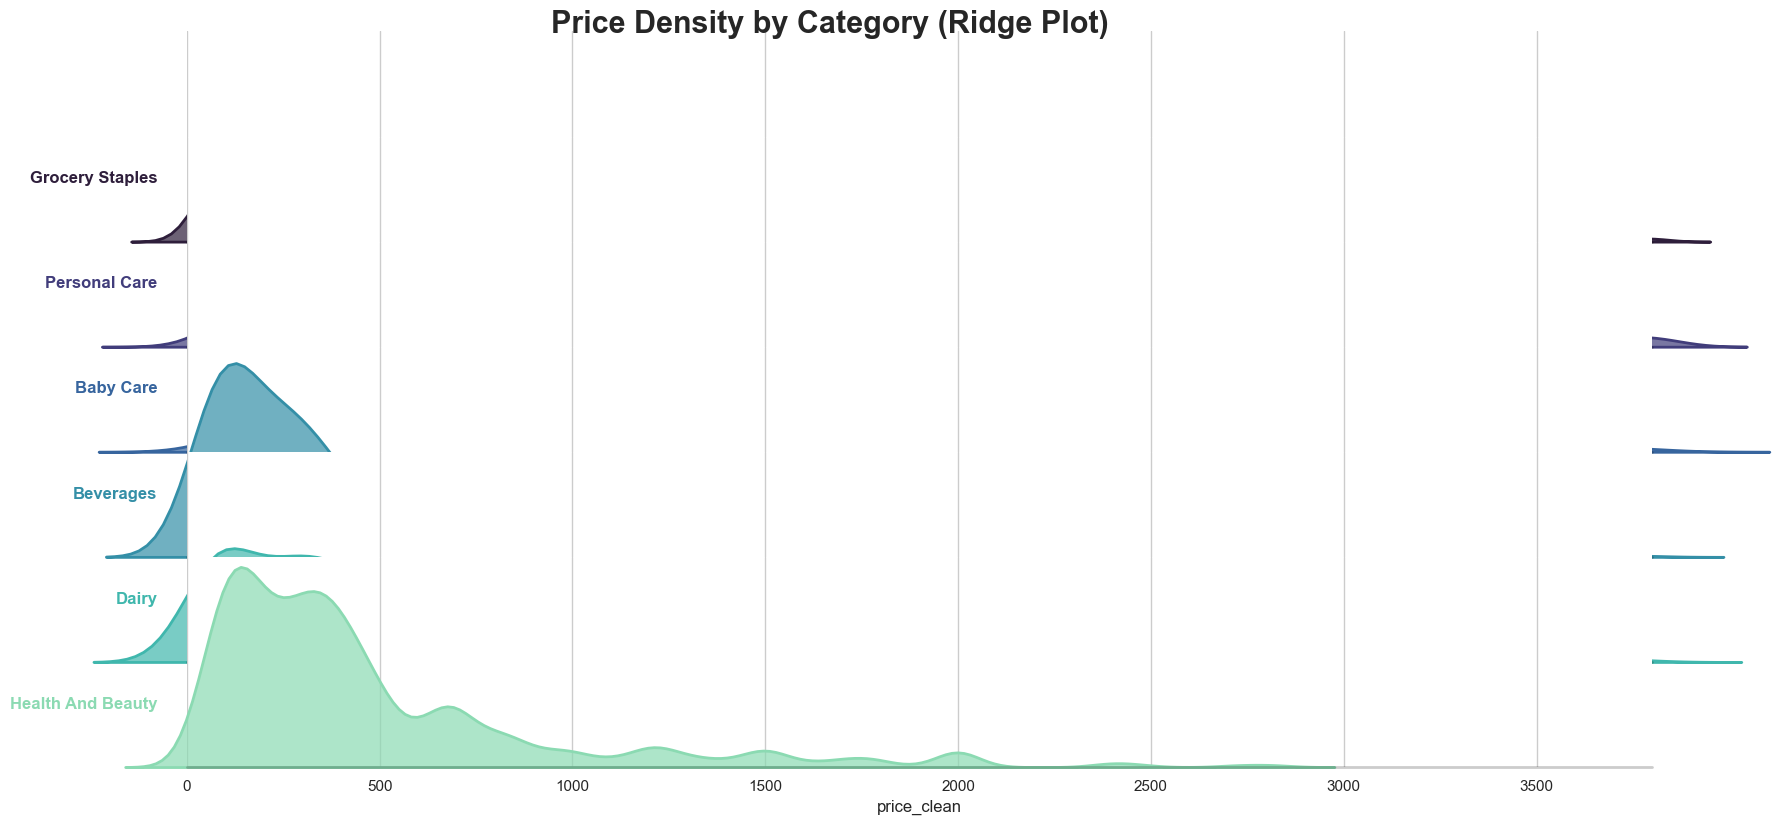

In [4]:
top_cats = df['category_normalized'].value_counts().head(6).index
ridge_df = df[df['category_normalized'].isin(top_cats) & (df['price_clean'] > 0)].copy()
# Use a tighter limit to zoom in on the densities (90th percentile)
upper_limit = ridge_df['price_clean'].quantile(0.90)
ridge_df = ridge_df[ridge_df['price_clean'] <= upper_limit]

sns.set_context('notebook')
g = sns.FacetGrid(ridge_df, row='category_normalized', hue='category_normalized',
                  aspect=12, height=1.4, palette='mako')

g.map(sns.kdeplot, 'price_clean', clip_on=False, fill=True, alpha=0.7, lw=2, bw_adjust=.6)
g.map(plt.axhline, y=0, lw=2, clip_on=False, color='black', alpha=0.2)

def label_row(x, color, label):
    ax = plt.gca()
    ax.text(-0.02, .3, label, fontweight='bold', color=color, ha='right', va='center',
            transform=ax.transAxes, fontsize=12)

g.map(label_row, 'price_clean')
g.fig.subplots_adjust(hspace=-.5)
g.set_titles(''); g.set(yticks=[], ylabel='', xlim=(0, upper_limit))
g.despine(bottom=True, left=True)
plt.suptitle('Price Density by Category (Ridge Plot)', fontsize=22, fontweight='bold', y=0.98)
plt.savefig(FIGURES_DIR / '01_price_ridge.png', dpi=150, bbox_inches='tight')
plt.show()
sns.set_context('talk')

## 1.4 — Data Quality Report

In [5]:
quality = pd.Series({
    'Total Rows':          f'{len(df):,}',
    'Missing Price':       f'{df["price_clean"].isnull().sum():,}',
    'Missing Size':        f'{df["size_normalized"].isnull().sum():,}',
    'PPU Coverage':        f'{df["price_per_unit"].notnull().mean()*100:.1f}%',
    'Unique Brands':       f'{df["brand_clean"].nunique():,}',
    'Unique Categories':   f'{df["category_normalized"].nunique()}',
    'Unique Stores':       f'{df["store_name"].nunique()}',
    'Unique Cities':       f'{df["city"].nunique()}',
}).to_frame('Value')

print('=== Data Quality Report ===')
display(quality)

=== Data Quality Report ===


,Value
Total Rows,"183,792"
Missing Price,0
Missing Size,"50,830"
PPU Coverage,72.3%
Unique Brands,"1,088"
Unique Categories,220
Unique Stores,3
Unique Cities,16
